# Reddit: vaccine attitudes (Lane A: you prompt, the agent builds)

**SISMID 2026 - Day 2, 11:00 (stretch).** Sam asked whether we can still get Reddit data
for research after the 2023 API changes killed Pushshift's public access. Short answer:
mostly yes, through **Arctic Shift**, an independent open-source Pushshift successor.


## About this data source

**Arctic Shift** (<https://arctic-shift.photon-reddit.com>). A free, no-key, community-run
API and data archive that picked up where Pushshift left off after Reddit revoked its
access in 2023. Verified live for this notebook: full-text search over post titles and
bodies, scoped to a subreddit or author, with real date-range filtering.

**Read before you build on this:**
- It is a **solo hobby project** (one GitHub maintainer), not an institution: *"no uptime
  or performance guarantees."* It could disappear the way Pushshift did.
- The project does not publicly document exactly how it collects data or address Reddit's
  terms of service. For a real (published) study, disclose the data's provenance and
  archive your pulled slice locally rather than depending on the live API.
- Sitewide keyword search does **not** work here — every query must be scoped to a
  `subreddit` or `author`. So instead of a single global keyword search, we watch a small
  set of vaccine-relevant subreddits, the same *account/community-watching* pattern used
  in the Bluesky notebook.
- "Be considerate": a couple of requests per second is fine; this notebook paces itself.


## Step 1: pull posts from vaccine-relevant subreddits

> *Using the Arctic Shift API (https://arctic-shift.photon-reddit.com/api, free, no key),*
> *pull recent posts (title + body) from a small set of vaccine-focused subreddits*
> *(vaccines, VaccineMyths, DebateVaccines, antivax) going back 6 months. Page through*
> *results with `sort=desc` and `before`, and return a tidy DataFrame.*

**Your check:** do these subreddits actually carry vaccine-attitude discourse, not just
off-topic noise?


In [1]:
# Agent's Arctic Shift pull:
import os, json, time, re
import urllib.request, urllib.parse
import pandas as pd, matplotlib.pyplot as plt

UA = {"User-Agent": "SISMID2026-course/1.0 (your-email@example.com)"}
BASE = "https://arctic-shift.photon-reddit.com/api"
FIELDS = "title,selftext,created_utc,subreddit,score,num_comments,author"


def cache_path(fname):
    for p in (f"../data/{fname}", f"data/{fname}", f"./{fname}"):
        if os.path.exists(p):
            return p
    return None


def fetch_page(subreddit, before_iso=None, limit=100):
    params = {"subreddit": subreddit, "sort": "desc", "limit": limit, "fields": FIELDS}
    if before_iso:
        params["before"] = before_iso
    url = f"{BASE}/posts/search?" + urllib.parse.urlencode(params)
    req = urllib.request.Request(url, headers=UA)
    return json.loads(urllib.request.urlopen(req, timeout=30).read()).get("data") or []


def fetch_subreddit_posts(subreddit, months_back=6, max_pages=6):
    """Paginate a subreddit's posts backward in time via sort=desc + before, until
    `months_back` is covered or `max_pages` is hit (keeps this considerate of a
    solo-maintained, no-SLA API)."""
    cutoff = pd.Timestamp.today() - pd.DateOffset(months=months_back)
    before, rows = None, []
    for _ in range(max_pages):
        batch = fetch_page(subreddit, before)
        if not batch:
            break
        rows.extend(batch)
        last_dt = pd.Timestamp(batch[-1]["created_utc"], unit="s")  # naive UTC, matches `cutoff`
        if last_dt < cutoff:
            break
        before = last_dt.isoformat()
        time.sleep(0.5)
    return rows


SUBREDDITS = ["vaccines", "VaccineMyths", "DebateVaccines", "antivax"]


def get_vaccine_posts(subreddits=SUBREDDITS, months_back=6):
    """Tidy DataFrame of recent posts across the vaccine-relevant subreddit watch list.
    Falls back to the cache on any failure."""
    try:
        rows = []
        for sr in subreddits:
            rows.extend(fetch_subreddit_posts(sr, months_back=months_back))
        if not rows:
            raise RuntimeError("no posts returned")
        df = pd.DataFrame(rows)
    except Exception as e:
        print(f"Live Arctic Shift pull failed ({type(e).__name__}): {e}")
        p = cache_path("reddit_vaccine_posts.csv")
        if p is None:
            raise RuntimeError("Live pull failed and no cache exists yet.") from e
        print("Using cached snapshot:", p)
        return pd.read_csv(p, parse_dates=["date"])
    df["date"] = pd.to_datetime(df["created_utc"], unit="s")
    df["text"] = (df["title"].fillna("") + " " + df["selftext"].fillna("")).str.replace("\n", " ", regex=False)
    return df[["date", "subreddit", "author", "score", "num_comments", "title", "text"]]


posts = get_vaccine_posts()
print(f"{len(posts)} posts, {posts['date'].min().date()} to {posts['date'].max().date()}")
print(posts["subreddit"].value_counts())
posts.head()


1400 posts, 2021-01-12 to 2026-07-22
subreddit
VACCINES          600
DebateVaccines    600
VaccineMyths      100
antivax           100
Name: count, dtype: int64


,date,subreddit,author,score,num_comments,title,text
0,2026-07-22 01:57:58,VACCINES,miniowlish,1,0,4th Rabies PEP concern,4th Rabies PEP concern
1,2026-07-22 01:55:35,VACCINES,TeamMarlin0502,1,0,What do I do unvaccinated baby…,What do I do unvaccinated baby… I am looking f...
2,2026-07-21 18:11:50,VACCINES,OddRecommendation782,1,0,How to go about getting vaccinated?,"How to go about getting vaccinated? I’m 19, an..."
3,2026-07-21 15:07:00,VACCINES,Iplantseeds,1,0,meningitis vaccine doctor,meningitis vaccine doctor My niece is entering...
4,2026-07-21 06:10:24,VACCINES,madds713,1,0,how was the 2nd meningitis vaccine?,how was the 2nd meningitis vaccine? i’m gettin...


## Step 2: tag attitude with a word-boundary keyword lexicon

> *Tag each post as 'hesitant/concerned', 'positive/reassured', 'both' or 'neutral' using*
> *two word-boundary keyword lists. This is a crude lexicon proxy, not a validated*
> *sentiment or stance model — same honesty standard as the disease-keyword flagging in*
> *the Bluesky notebook.*

**Your check:** read a handful of posts in each tag. Does the label roughly match what a
human would say?


In [2]:
# Agent's attitude tagging:
HESITANCY_TERMS = ["hesitant", "hesitancy", "anti-vax", "antivax", "anti vax", "refuse",
                   "refusing", "side effect", "side effects", "autism", "toxin", "toxins",
                   "skeptical", "distrust", "scared", "worried", "anxious", "anxiety"]
POSITIVE_TERMS = ["protect", "protects", "protected", "protection", "safe", "safety",
                  "recommend", "recommended", "grateful", "immunized", "immunised",
                  "trust the science", "lifesaving", "life-saving", "effective"]

hes_pat = re.compile(r"\b(" + "|".join(re.escape(t) for t in HESITANCY_TERMS) + r")\b", re.I)
pos_pat = re.compile(r"\b(" + "|".join(re.escape(t) for t in POSITIVE_TERMS) + r")\b", re.I)


def tag_attitude(text):
    h = len(hes_pat.findall(text))
    p = len(pos_pat.findall(text))
    if h and p:
        return "mixed", h, p
    if h:
        return "hesitant/concerned", h, p
    if p:
        return "positive/reassured", h, p
    return "neutral", h, p


tags = posts["text"].apply(tag_attitude)
posts["attitude"] = [t[0] for t in tags]
posts["hesitancy_hits"] = [t[1] for t in tags]
posts["positive_hits"] = [t[2] for t in tags]

print(posts["attitude"].value_counts())
print("\nexample hesitant/concerned post:")
print(" ", posts.loc[posts["attitude"] == "hesitant/concerned", "title"].iloc[0])
print("example positive/reassured post:")
print(" ", posts.loc[posts["attitude"] == "positive/reassured", "title"].iloc[0])

attitude
neutral               957
hesitant/concerned    201
positive/reassured    172
mixed                  70
Name: count, dtype: int64

example hesitant/concerned post:
  How to go about getting vaccinated?
example positive/reassured post:
  What do I do unvaccinated baby…


## Step 3: visualize

> *Plot the attitude tally by subreddit, and the weekly trend of hesitant vs positive*
> *posts over the pulled window.*


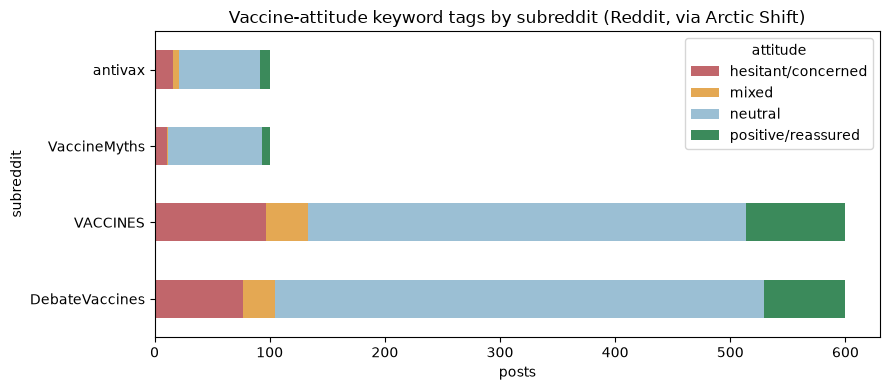

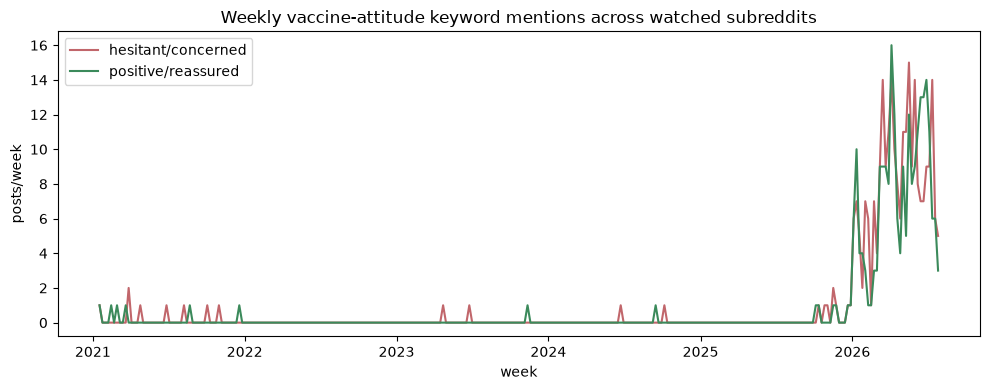

In [3]:
# Agent's attitude visualizations:
tab = pd.crosstab(posts["subreddit"], posts["attitude"])
tab = tab[[c for c in ["hesitant/concerned", "mixed", "neutral", "positive/reassured"] if c in tab.columns]]
tab.plot(kind="barh", stacked=True, figsize=(9, 4),
         color={"hesitant/concerned": "#C1666B", "mixed": "#E4A853",
                "neutral": "#9bbfd4", "positive/reassured": "#3B8A5B"})
plt.xlabel("posts")
plt.title("Vaccine-attitude keyword tags by subreddit (Reddit, via Arctic Shift)")
plt.tight_layout()
plt.savefig("../reddit_vaccine_attitude_by_subreddit.png", dpi=150)
plt.show()

weekly = (posts.set_index("date")
               .assign(is_hesitant=lambda d: d["attitude"].isin(["hesitant/concerned", "mixed"]),
                       is_positive=lambda d: d["attitude"].isin(["positive/reassured", "mixed"]))
               .resample("W")[["is_hesitant", "is_positive"]].sum())
plt.figure(figsize=(10, 4))
plt.plot(weekly.index, weekly["is_hesitant"], color="#C1666B", label="hesitant/concerned")
plt.plot(weekly.index, weekly["is_positive"], color="#3B8A5B", label="positive/reassured")
plt.ylabel("posts/week")
plt.xlabel("week")
plt.title("Weekly vaccine-attitude keyword mentions across watched subreddits")
plt.legend()
plt.tight_layout()
plt.savefig("../reddit_vaccine_attitude_weekly.png", dpi=150)
plt.show()

## Step 4: sanity-check and save

> *Report post counts per subreddit, the attitude tally, and save a tidy CSV.*


In [4]:
# Agent's checks + save:
print("posts per subreddit:")
print(posts["subreddit"].value_counts())
print("\noverall attitude tally:")
print(posts["attitude"].value_counts())
print("\nshare hesitant/concerned or mixed:",
      round(posts["attitude"].isin(["hesitant/concerned", "mixed"]).mean(), 3))

posts.to_csv("../data/reddit_vaccine_posts.csv", index=False)
print("\nsaved reddit_vaccine_posts.csv:", posts.shape)

posts per subreddit:
subreddit
VACCINES          600
DebateVaccines    600
VaccineMyths      100
antivax           100
Name: count, dtype: int64

overall attitude tally:
attitude
neutral               957
hesitant/concerned    201
positive/reassured    172
mixed                  70
Name: count, dtype: int64

share hesitant/concerned or mixed: 0.194

saved reddit_vaccine_posts.csv: (1400, 10)


## Reflection

- This is a **keyword-lexicon proxy for attitude**, not a validated sentiment/stance
  model — a post using "safe" sarcastically, or negating a hesitancy term ("not scared
  anymore"), will be mis-tagged. Read examples before trusting the tally.
- **Subreddit selection is the whole ballgame.** r/vaccines, r/VaccineMyths,
  r/DebateVaccines and r/antivax each attract a different slice of vaccine discourse
  (clinical Q&A vs. mythbusting vs. open debate vs. anti-anti-vax satire) — this is a
  curated community sample, not a representative one.
- **Data provenance:** pulled via Arctic Shift, an independent, unofficial, solo-maintained
  successor to Pushshift. Fine for this exercise; disclose it and archive your slice if
  this ever becomes real (published) research.
- **Stretch:** swap in your own subreddit list and keyword lexicon for a different topic.
